# Part 1

In [1]:
import pandas as pd
import numpy as np

# 1) Load the given dataset
df = pd.read_excel(r"D:\Ali\Project Portfolio\ML Projects\KNN\ML Project - KNN Loan Applicant Credit Risk Analysis.xlsx")
df

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1
...,...,...,...,...,...,...,...
8990,30.80,3,3,0.596748,763,0,0
8991,31.83,3,6,0.986793,532,0,0
8992,32.67,2,5,0.628330,590,0,0
8993,37.00,3,3,0.797193,812,0,0


In [2]:
# 2) Check for the null values 
print("--- Null Values ---")
print(df.isnull().sum())

--- Null Values ---
Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64


In [3]:
# 3) Get basic information from data 
print("\n--- Basic Information ---")
df.info()


--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


In [4]:
# 4) Describe the dataset 
print("\n--- Dataset Description ---")
print(df.describe())


--- Dataset Description ---
               Age  Total Work Experience  Number of years in city  \
count  8995.000000            8995.000000              8995.000000   
mean     38.808202               2.131073                 4.288160   
std      10.203371               0.892141                 1.269416   
min      18.100000               1.000000                 1.000000   
25%      30.830000               1.000000                 3.000000   
50%      37.200000               2.000000                 4.000000   
75%      45.400000               3.000000                 5.000000   
max      83.800000               5.000000                 6.000000   

       Cost to Request Ratio  Cibil score  Overdrafts past12months  \
count            8995.000000  8995.000000              8995.000000   
mean                0.831183   752.626570                 0.322068   
std                 0.490216    67.645792                 0.914998   
min                 0.008466   351.000000                 0.

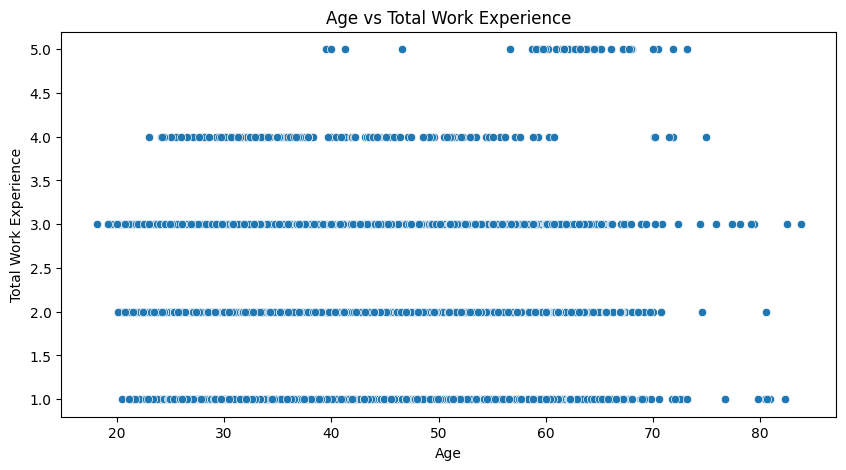

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5) Display scatterplot between age & Total work Experience 
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Age', y='Total Work Experience', data=df)
plt.title('Age vs Total Work Experience')
plt.show()

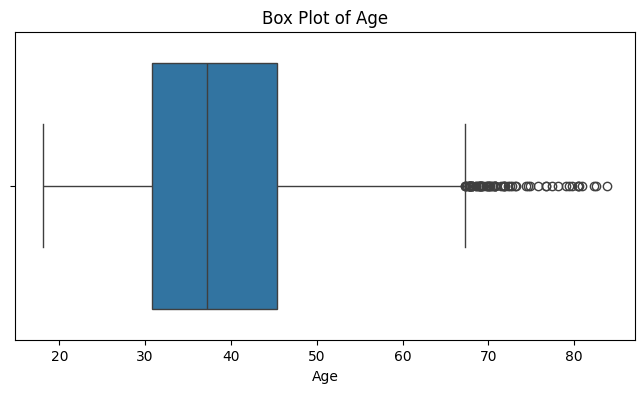

In [6]:
# 6) Display box plot for age 
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')
plt.show()

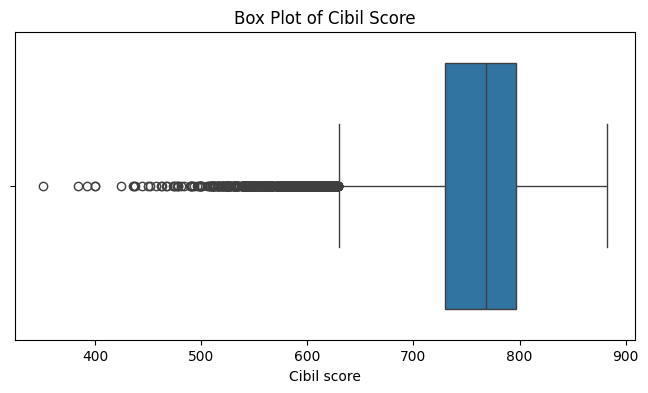

In [7]:
# 7) Display box plot for Cibil score 
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Cibil score'])
plt.title('Box Plot of Cibil Score')
plt.show()

In [8]:
# 8) Create target and features data where target is Total bounces past 12 months
X = df.drop('Total bounces past12months', axis=1)
y = df['Total bounces past12months']

# Part 2

In [9]:
from sklearn.model_selection import train_test_split

# 1) Split data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# 2) Create a KNN classifier between Features and target data
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
# 3) Display the test score 
print(f"\nKNN (k=5) Test Score: {knn.score(X_test, y_test):.4f}")


KNN (k=5) Test Score: 0.6559


In [12]:
# 4) Display the training score 
print(f"KNN (k=5) Training Score: {knn.score(X_train, y_train):.4f}")

KNN (k=5) Training Score: 0.6574


In [13]:
from sklearn.metrics import accuracy_score

# 5) Print the accuracy score 
y_pred = knn.predict(X_test)
print(f"KNN (k=5) Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

KNN (k=5) Accuracy Score: 0.6559


In [14]:
# 6) Display training and testing score for all the 1 to 14 k values
k_range = range(1, 15)
train_scores = []
test_scores = []

print("\n--- K-Value Analysis ---")
print(f"{'K Value':<10} | {'Train Score':<12} | {'Test Score':<12}")
print("-" * 40)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    tr_score = model.score(X_train, y_train)
    te_score = model.score(X_test, y_test)
    
    train_scores.append(tr_score)
    test_scores.append(te_score)
    
    print(f"{k:<10} | {tr_score:<12.4f} | {te_score:<12.4f}")


--- K-Value Analysis ---
K Value    | Train Score  | Test Score  
----------------------------------------
1          | 1.0000       | 0.5464      
2          | 0.7408       | 0.6259      
3          | 0.7066       | 0.6270      
4          | 0.6862       | 0.6370      
5          | 0.6787       | 0.6470      
6          | 0.6681       | 0.6531      
7          | 0.6629       | 0.6498      
8          | 0.6608       | 0.6543      
9          | 0.6574       | 0.6559      
10         | 0.6561       | 0.6593      
11         | 0.6547       | 0.6593      
12         | 0.6541       | 0.6593      
13         | 0.6545       | 0.6593      
14         | 0.6536       | 0.6587      


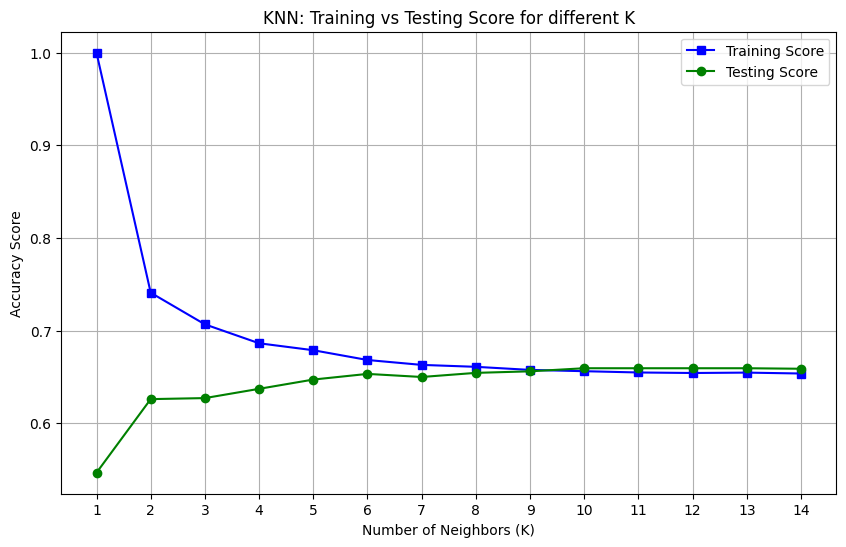

In [15]:
# Final Visualization for K-Value optimization
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Training Score', marker='s', color='blue')
plt.plot(k_range, test_scores, label='Testing Score', marker='o', color='green')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.title('KNN: Training vs Testing Score for different K')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()